Laboratório 1 - Análise de Dados Financeiros

Objetivo:

Neste laboratório será realizada uma análise de três ações negociadas na bolsa de valores durante o ano de 2019.

Os ativos analisados são:

Ticker          Empresa
HPE             Hewlett Packard Enterprise
MRNA            Moderna Inc.
PCG             Pacific Gas &Electric Company

Durante o laboratório serão desenvolvidas análises estatísticas e gráficas utilizando Python.

In [26]:
# 1. Importação das bibliotecas

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import gaussian_kde

import yfinance as yf

#Para validar a versão do Python e do ambiente Anaconda
import sys
print(sys.executable)
print(sys.version)


plt.style.use("ggplot")

c:\Users\gerson.manuel\Downloads\Labs_Univ_Analise_Dados\Lab_01_Financas\.venv\Scripts\python.exe
3.13.0 (tags/v3.13.0:60403a5, Oct  7 2024, 09:38:07) [MSC v.1941 64 bit (AMD64)]


In [28]:
#2. Definindo os activos no site das cotações UCI

ativos = [
    "HPE",
    "MRNA",
    "PCG"
]

inicio = "2019-01-01"
fim = "2019-12-31"

In [29]:
import yfinance as yf

dados = {}

for ativo in ativos:
    dados[ativo] = yf.download(
        ativo,
        start=inicio,
        end=fim,
        auto_adjust=True,
        progress=False
    )

    print(f"{ativo}: {dados[ativo].shape[0]} registros baixados.")

HPE: 251 registros baixados.
MRNA: 251 registros baixados.
PCG: 251 registros baixados.


In [30]:
# 3. Verificando cabeçalhos e colunas:
dados["HPE"].head()
dados["HPE"].columns

MultiIndex([( 'Close', 'HPE'),
            (  'High', 'HPE'),
            (   'Low', 'HPE'),
            (  'Open', 'HPE'),
            ('Volume', 'HPE')],
           names=['Price', 'Ticker'])

In [31]:
#4. Calculando a rentabilidade diária
#A rentabilidade diária será calculada por: Rt = Pt - Pt-1 / Pt-1
#No Pandas isso corresponde ao método pct_change().

retornos = pd.DataFrame()

for ativo in ativos:
    retornos[ativo] = dados[ativo]["Close"].pct_change()

retornos = retornos.dropna()

retornos.head()

,HPE,MRNA,PCG
Date,,,
2019-01-03,-0.020802,0.011089,0.006303
2019-01-04,0.047041,0.094193,0.018789
2019-01-07,0.019565,-0.040684,-0.223361
2019-01-08,-0.019190,0.041795,-0.073351
2019-01-09,0.018841,-0.036578,0.015376


In [32]:
# 5. Média das rentabilidades
media = retornos.mean()
print(media)

# Encontrando a acção com maior média
melhor_acao = media.idxmax()
print(melhor_acao)


HPE     0.000909
MRNA    0.001604
PCG     0.000988
dtype: float64
MRNA


<Figure size 1200x600 with 0 Axes>

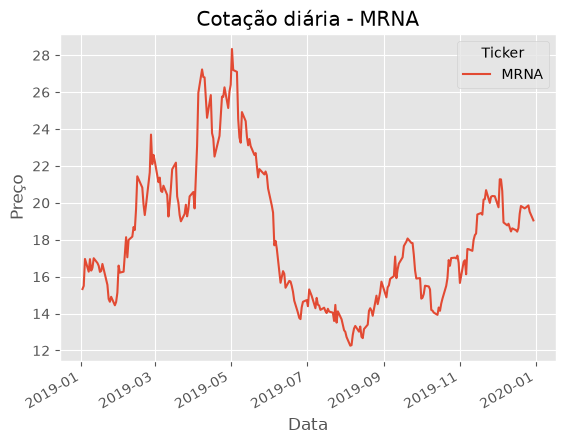

In [33]:
# 6. Gráfico da ação com maior retorno médio
plt.figure(figsize=(12,6))

dados[melhor_acao]["Close"].plot()

plt.title(f"Cotação diária - {melhor_acao}")

plt.xlabel("Data")

plt.ylabel("Preço")

plt.show()

Explicação/Insights:
Este gráfico mostra a evolução do preço da ação durante todo o ano de 2019.

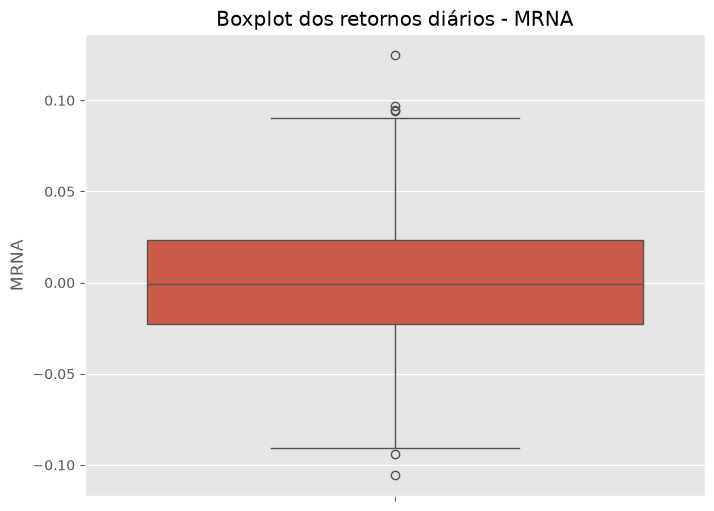

In [34]:
# 7. Boxplot da ação com maior retorno médio
plt.figure(figsize=(8,6))

sns.boxplot(
    y=retornos[melhor_acao]
)

plt.title(f"Boxplot dos retornos diários - {melhor_acao}")

plt.show()

Explicação/Insights:
O boxplot apresenta: mediana; quartis;dispersão; outliers

In [35]:
# 8. Encontrando a maior variância
variancias = retornos.var()
print(variancias)

acao_maior_var = variancias.idxmax()
print(acao_maior_var)

HPE     0.000303
MRNA    0.001481
PCG     0.008222
dtype: float64
PCG


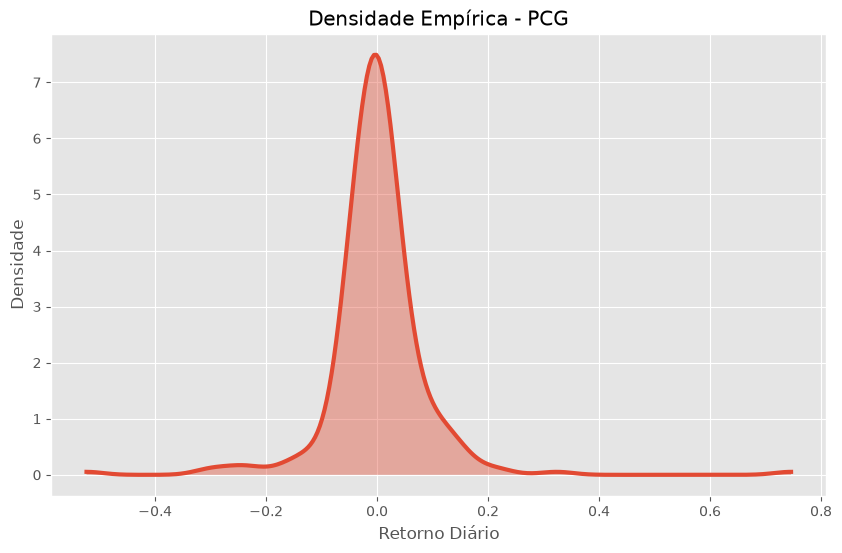

In [36]:
# 9. Densidade empírica
serie = retornos[acao_maior_var]

densidade = gaussian_kde(serie)

x = np.linspace(
    serie.min(),
    serie.max(),
    300
)

plt.figure(figsize=(10,6))

plt.plot(
    x,
    densidade(x),
    linewidth=3
)

plt.fill_between(
    x,
    densidade(x),
    alpha=0.4
)

plt.title(f"Densidade Empírica - {acao_maior_var}")

plt.xlabel("Retorno Diário")

plt.ylabel("Densidade")

plt.show()

Explicação/Insights:
A densidade empírica permite visualizar como os retornos se distribuem.
Quanto maior o pico, maior a concentração de observações naquele intervalo.

In [37]:
# 10. Matriz de covariância
cov = retornos.cov()
cov

,HPE,MRNA,PCG
HPE,0.000303,0.000123,0.000052
MRNA,0.000123,0.001481,0.000166
PCG,0.000052,0.000166,0.008222


In [38]:
# Encontrando a menor covariância
menor = cov.stack().idxmin()

print(menor)

('HPE', 'PCG')


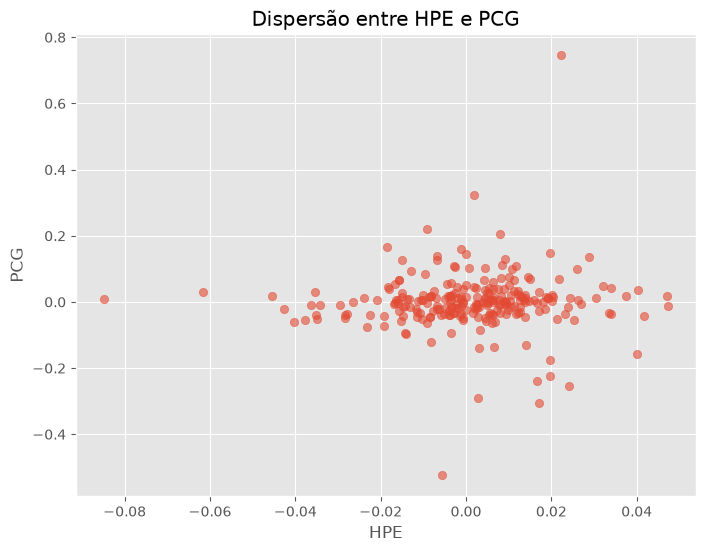

In [40]:
# 11. Scatter Plot
x = menor[0]

y = menor[1]

plt.figure(figsize=(8,6))

plt.scatter(
    retornos[x],
    retornos[y],
    alpha=0.6
)

plt.xlabel(x)

plt.ylabel(y)

plt.title(f"Dispersão entre {x} e {y}")

plt.show()

Explicação/Insights:
Este gráfico mostra a relação entre os retornos das duas ações.
Caso exista correlação positiva, os pontos tenderão a formar uma reta crescente.

In [41]:
# 12. Estatísticas finais
estatisticas = pd.DataFrame({
    "Média": retornos.mean(),
    "Variância": retornos.var(),
    "Desvio Padrão": retornos.std()
})

estatisticas

,Média,Variância,Desvio Padrão
HPE,0.000909,0.000303,0.017393
MRNA,0.001604,0.001481,0.038488
PCG,0.000988,0.008222,0.090677


## Explicação dos resultados

Com estas análises foi possível:

Obter as cotações históricas das acções durante o ano de 2019;
Calcular os retornos diários utilizando a variação percentual;
Identificar a acção com maior retorno médio diário;
Visualizar sua evolução através de um gráfico temporal;
Analisar sua distribuição utilizando um boxplot;
Identificar a ação com maior variabilidade dos retornos;
Visualizar a densidade empírica desses retornos;
Calcular a matriz de covariância;
Identificar o par de ações com menor covariância;
Construir o gráfico de dispersão para avaliar a relação entre esses activos